# 03 - 细胞类型注释 (Cell Type Annotation)

目标：
 1. 计算每个 Leiden 簇的差异表达基因（DEG）
 2. 基于已知 PBMC marker 基因库进行自动注释
 3. 可视化 marker 基因表达，验证注释
 4. 将注释结果与拓扑特征关联分析

## 1. 加载数据

In [1]:
import sys
sys.path.append("..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scanpy as sc

sc.settings.verbosity = 3
sc.settings.set_figure_params(dpi=80, facecolor="white")

from src import config
from src.io import load_h5ad, save_h5ad
from src.annotation import (
    load_marker_db, 
    rank_cluster_genes, 
    get_top_markers, 
    score_cell_types,
    annotate_clusters,
    add_annotation_to_adata
)

In [2]:
# 加载带聚类的数据
adata = load_h5ad("pbmc3k_clustered.h5ad")
print(f"数据: {adata.n_obs} 细胞 × {adata.n_vars} 基因")
print(f"Leiden 簇: {adata.obs['leiden'].cat.categories.tolist()}")

数据: 2638 细胞 × 2000 基因
Leiden 簇: ['0', '1', '2', '3', '4', '5']


## 2. 计算差异表达基因（DEG）

In [3]:
# 使用 Wilcoxon rank-sum 检验，基于 raw 数据（全部基因）
rank_cluster_genes(adata, group_key="leiden", method="wilcoxon")

ranking genes
    finished: added to `.uns['rank_genes']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:00:22)


AnnData object with n_obs × n_vars = 2638 × 2000
    obs: 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'leiden'
    var: 'gene_ids', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'hvg', 'leiden', 'leiden_colors', 'log1p', 'neighbors', 'pca', 'umap', 'rank_genes'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'

In [4]:
# 查看每个簇的 top 10 marker
for cid in adata.obs["leiden"].cat.categories:
    top_df = get_top_markers(adata, cid, n_genes=10)
    print(f"\n=== Cluster {cid} ===")
    print(top_df[["names", "scores", "pvals_adj"]].head(5).to_string(index=False))



=== Cluster 0 ===
 names    scores     pvals_adj
  TPT1 27.799952 1.240991e-167
RPS27A 26.507753 1.972442e-152
 RPL13 25.674662 4.486319e-143
   LTB 24.514936 1.574950e-130
 RPS3A 24.345989 9.132781e-129

=== Cluster 1 ===
 names    scores     pvals_adj
   FTL 38.003166  0.000000e+00
  FTH1 37.671284 1.466912e-307
TYROBP 37.257156 5.410059e-301
  CST3 36.742970 7.528552e-293
   LYZ 36.613766 6.909229e-291

=== Cluster 2 ===
names    scores     pvals_adj
 NKG7 32.051964 4.122681e-222
 CST7 27.642637 3.421762e-165
 GZMA 27.582466 1.204100e-164
  B2M 27.103188 4.515310e-159
 CTSW 26.662771 5.090754e-154

=== Cluster 3 ===
   names    scores     pvals_adj
    CD74 28.924610 1.171167e-180
   CD79A 27.881653 4.453716e-168
 HLA-DRA 27.565960 1.899259e-164
   CD79B 26.509001 3.816322e-152
HLA-DPB1 25.804678 3.142990e-144

=== Cluster 4 ===
   names   scores    pvals_adj
HLA-DPA1 9.400325 7.607716e-18
HLA-DPB1 9.364963 7.607716e-18
 HLA-DRA 9.059811 8.711786e-17
HLA-DRB1 9.020483 9.363111e-17


## 3. 基于 Marker 基因库自动注释

In [5]:
# 加载 marker 库
marker_db = load_marker_db()
print("Marker 库加载完成，包含:", list(marker_db.keys()))

Marker 库加载完成，包含: ['T cells', 'B cells', 'NK cells', 'Monocytes', 'Dendritic cells', 'Platelets']


In [6]:
# 计算每个簇对各细胞类型的得分
score_df = score_cell_types(adata, marker_db)
print("\n细胞类型得分矩阵:")
print(score_df.round(3))


细胞类型得分矩阵:
        T cells  B cells  NK cells  Monocytes  Dendritic cells  Platelets
leiden                                                                   
0         1.009    0.439     0.228      0.431            0.118      0.008
1         0.074    0.877     0.296      3.140            1.335      0.048
2         0.884    0.551     3.092      0.740            0.130      0.015
3         0.058    2.576     0.159      0.395            0.110      0.014
4         0.269    1.339     0.346      2.157            2.601      0.028
5         0.000    0.511     0.091      0.651            0.646      4.624


e:\project\scRNA-topo-pipeline\notebook\..\src\annotation.py:73: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_by_cluster = cluster_scores.groupby("leiden")["score"].mean()
e:\project\scRNA-topo-pipeline\notebook\..\src\annotation.py:73: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_by_cluster = cluster_scores.groupby("leiden")["score"].mean()
e:\project\scRNA-topo-pipeline\notebook\..\src\annotation.py:73: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the 

In [7]:
# 自动注释
annotations = annotate_clusters(score_df, top_n=1)
print("\n自动注释结果:")
for k, v in annotations.items():
    print(f"  Cluster {k}: {v}")


自动注释结果:
  Cluster 0: T cells
  Cluster 1: Monocytes
  Cluster 2: NK cells
  Cluster 3: B cells
  Cluster 4: Dendritic cells
  Cluster 5: Platelets


In [8]:
# 写入 adata
add_annotation_to_adata(adata, annotations, score_df)

AnnData object with n_obs × n_vars = 2638 × 2000
    obs: 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'leiden', 'cell_type'
    var: 'gene_ids', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'hvg', 'leiden', 'leiden_colors', 'log1p', 'neighbors', 'pca', 'umap', 'rank_genes', 'cell_type_scores'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'

In [9]:
# 保存注释结果
annot_df = pd.DataFrame({
    "leiden": adata.obs["leiden"].cat.categories,
    "cell_type": [annotations[c] for c in adata.obs["leiden"].cat.categories],
    "n_cells": adata.obs["leiden"].value_counts().sort_index().values
})
annot_df.to_csv(config.TABLES_DIR / "03_cluster_annotation.csv", index=False)
print("\n注释表已保存")


注释表已保存


## 4. 可视化验证

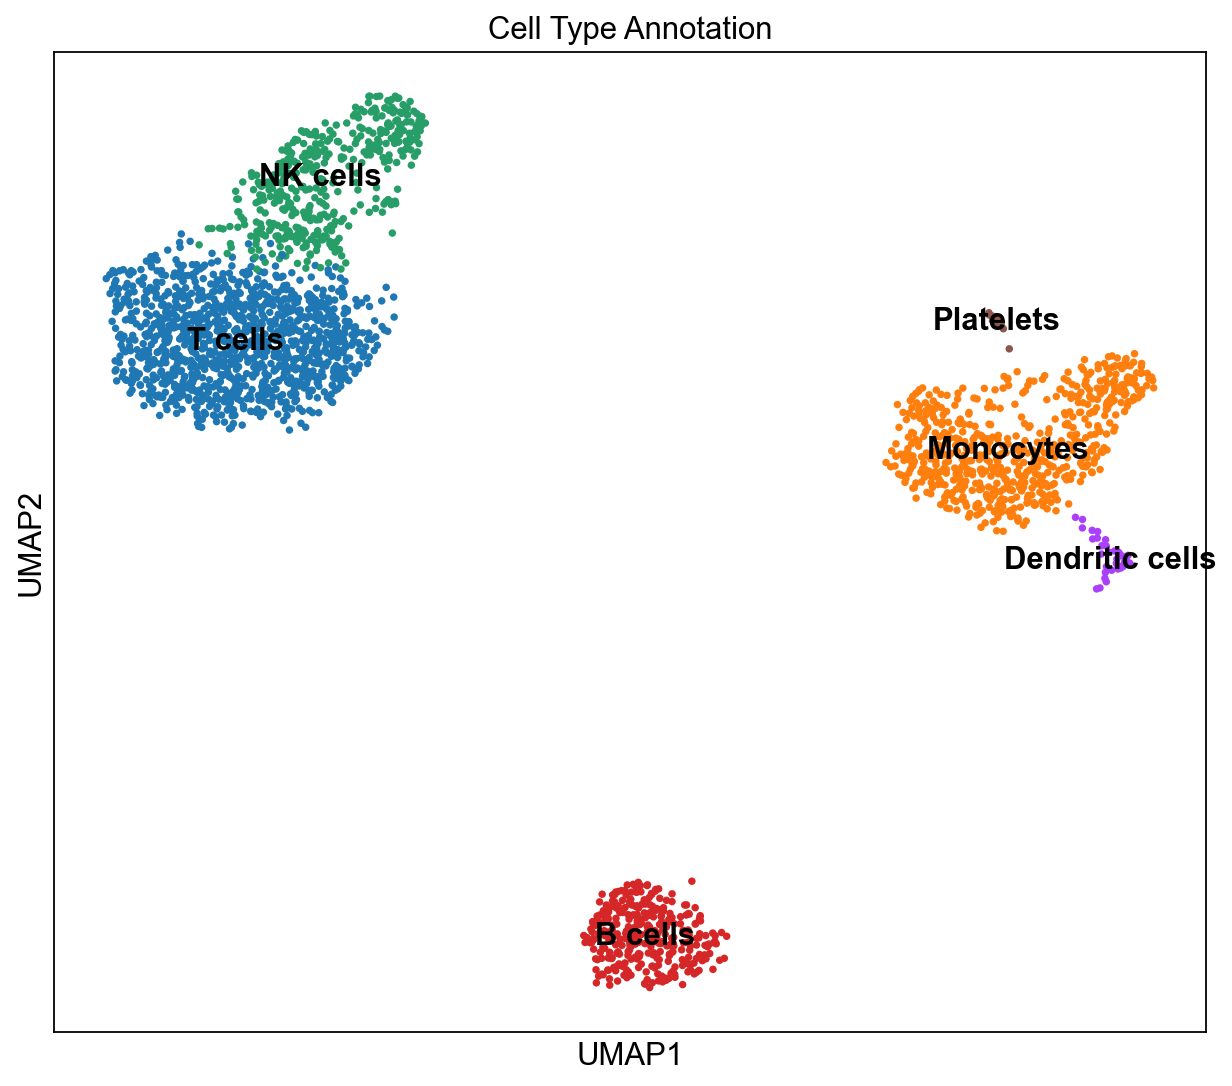

In [10]:
# 4.1 UMAP 按细胞类型着色
fig, ax = plt.subplots(figsize=(8, 7))
sc.pl.umap(adata, color="cell_type", ax=ax, show=False, 
           legend_loc="on data", title="Cell Type Annotation")
plt.tight_layout()
plt.savefig(config.FIGURES_DIR / "03_umap_cell_type.png", dpi=150, bbox_inches="tight")
plt.show()

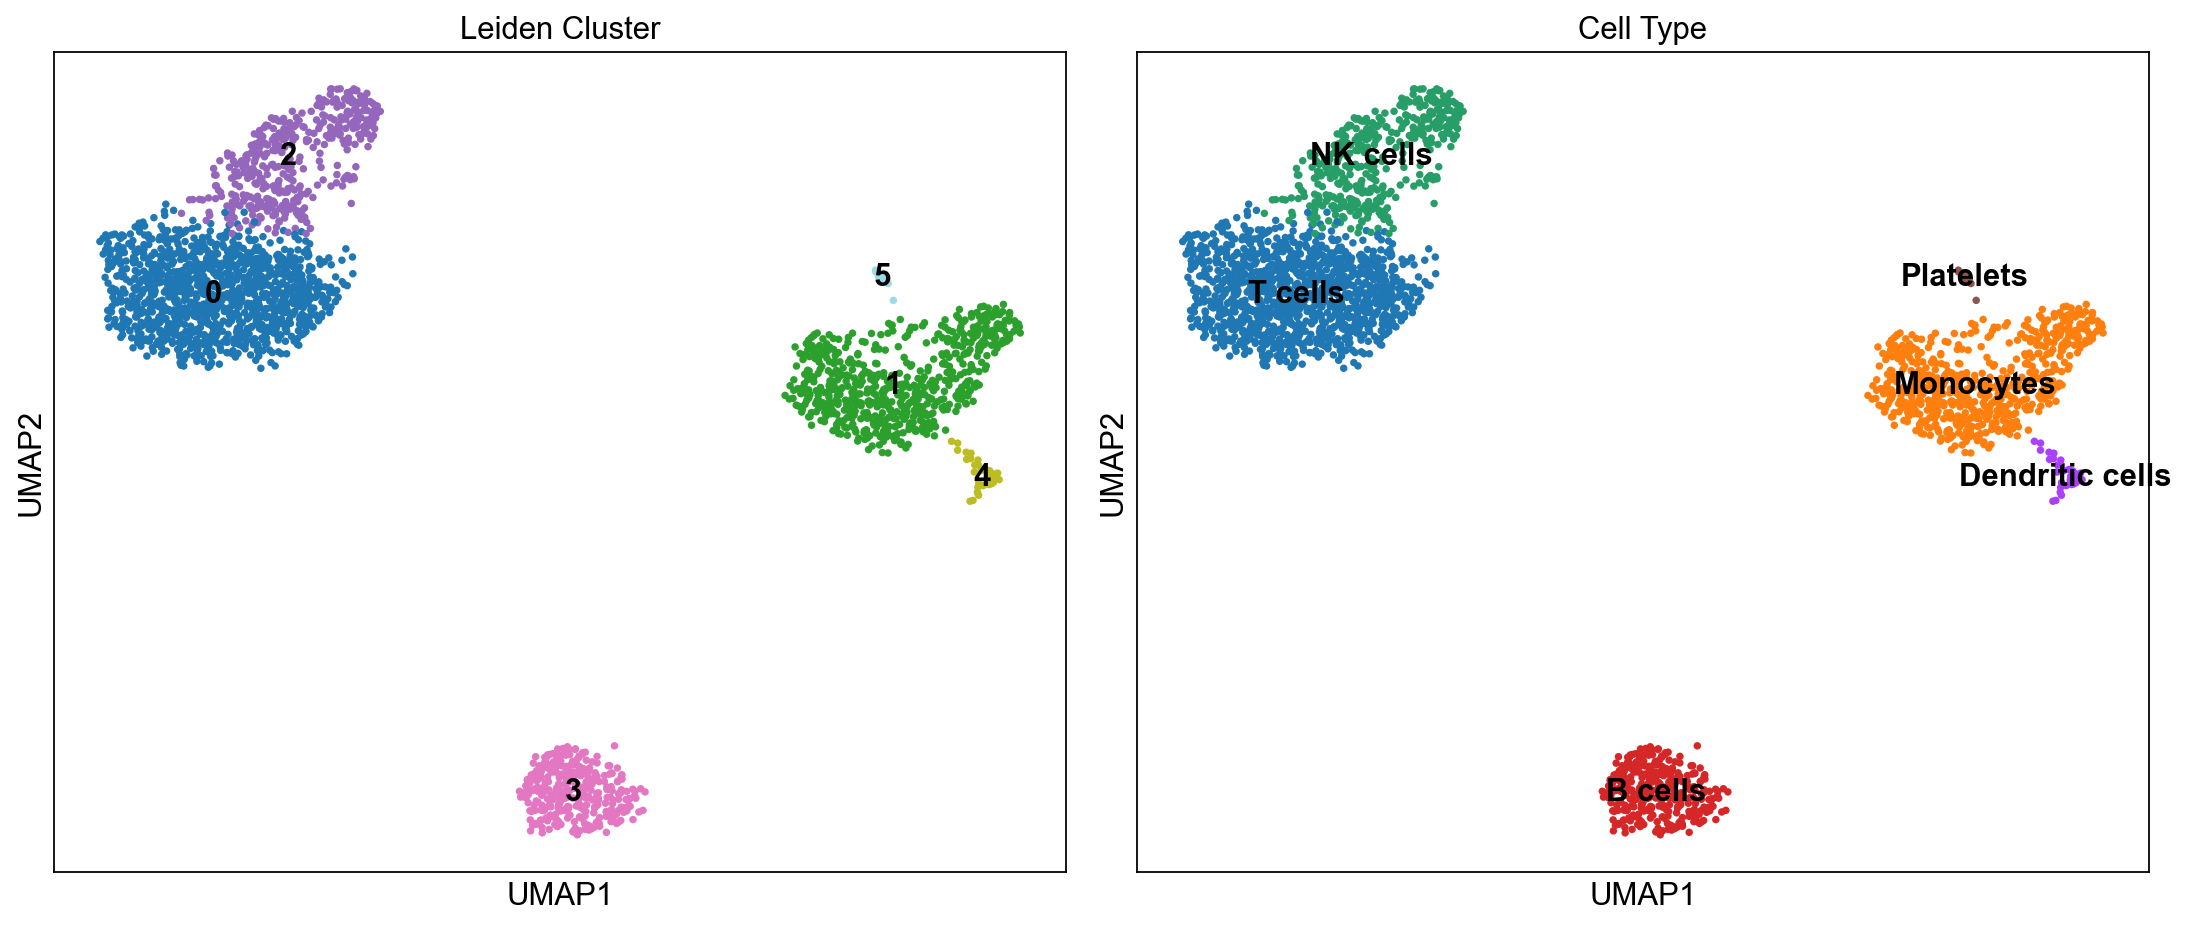

In [11]:
# 4.2 同时展示 Leiden 编号和注释
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sc.pl.umap(adata, color="leiden", ax=axes[0], show=False, legend_loc="on data", title="Leiden Cluster")
sc.pl.umap(adata, color="cell_type", ax=axes[1], show=False, legend_loc="on data", title="Cell Type")
plt.tight_layout()
plt.savefig(config.FIGURES_DIR / "03_umap_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. 关键 Marker 基因表达热图

In [12]:
# 选取每个细胞类型的代表性 marker 进行展示
key_markers = [
    "CD3D", "CD4", "CD8A",           # T cells
    "CD79A", "MS4A1",                # B cells
    "NKG7", "GNLY",                  # NK cells
    "CD14", "LYZ", "FCGR3A",         # Monocytes
    "FCER1A", "CST3",                # DC
    "PPBP", "PF4"                    # Platelets
]

# 过滤掉数据中没有的基因
available_markers = [m for m in key_markers if m in adata.raw.var_names]

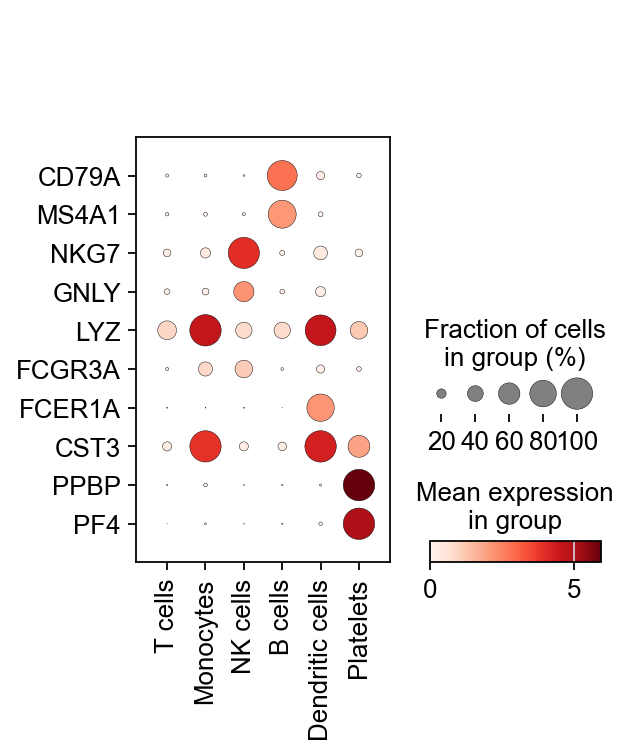

In [13]:
sc.pl.dotplot(
    adata,
    var_names=available_markers,
    groupby="cell_type",
    use_raw=True,
    dendrogram=False,
    swap_axes=True,
    save="_markers.png"
)

## 6. 拓扑特征 × 细胞类型关联分析

将 Phase 2 的拓扑统计与细胞类型注释结合，回答：
"哪种细胞类型在拓扑上最独立？"

In [15]:
# 加载拓扑统计
topo_stats = pd.read_csv(config.TABLES_DIR / "02_cluster_topology_stats.csv")

# 合并注释
topo_stats["cell_type"] = topo_stats["cluster"].astype(str).map(annotations)

C:\Users\Admin\AppData\Local\Temp\ipykernel_16512\2885333348.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=topo_stats, x="cell_type", y="mean_persistence_h0",


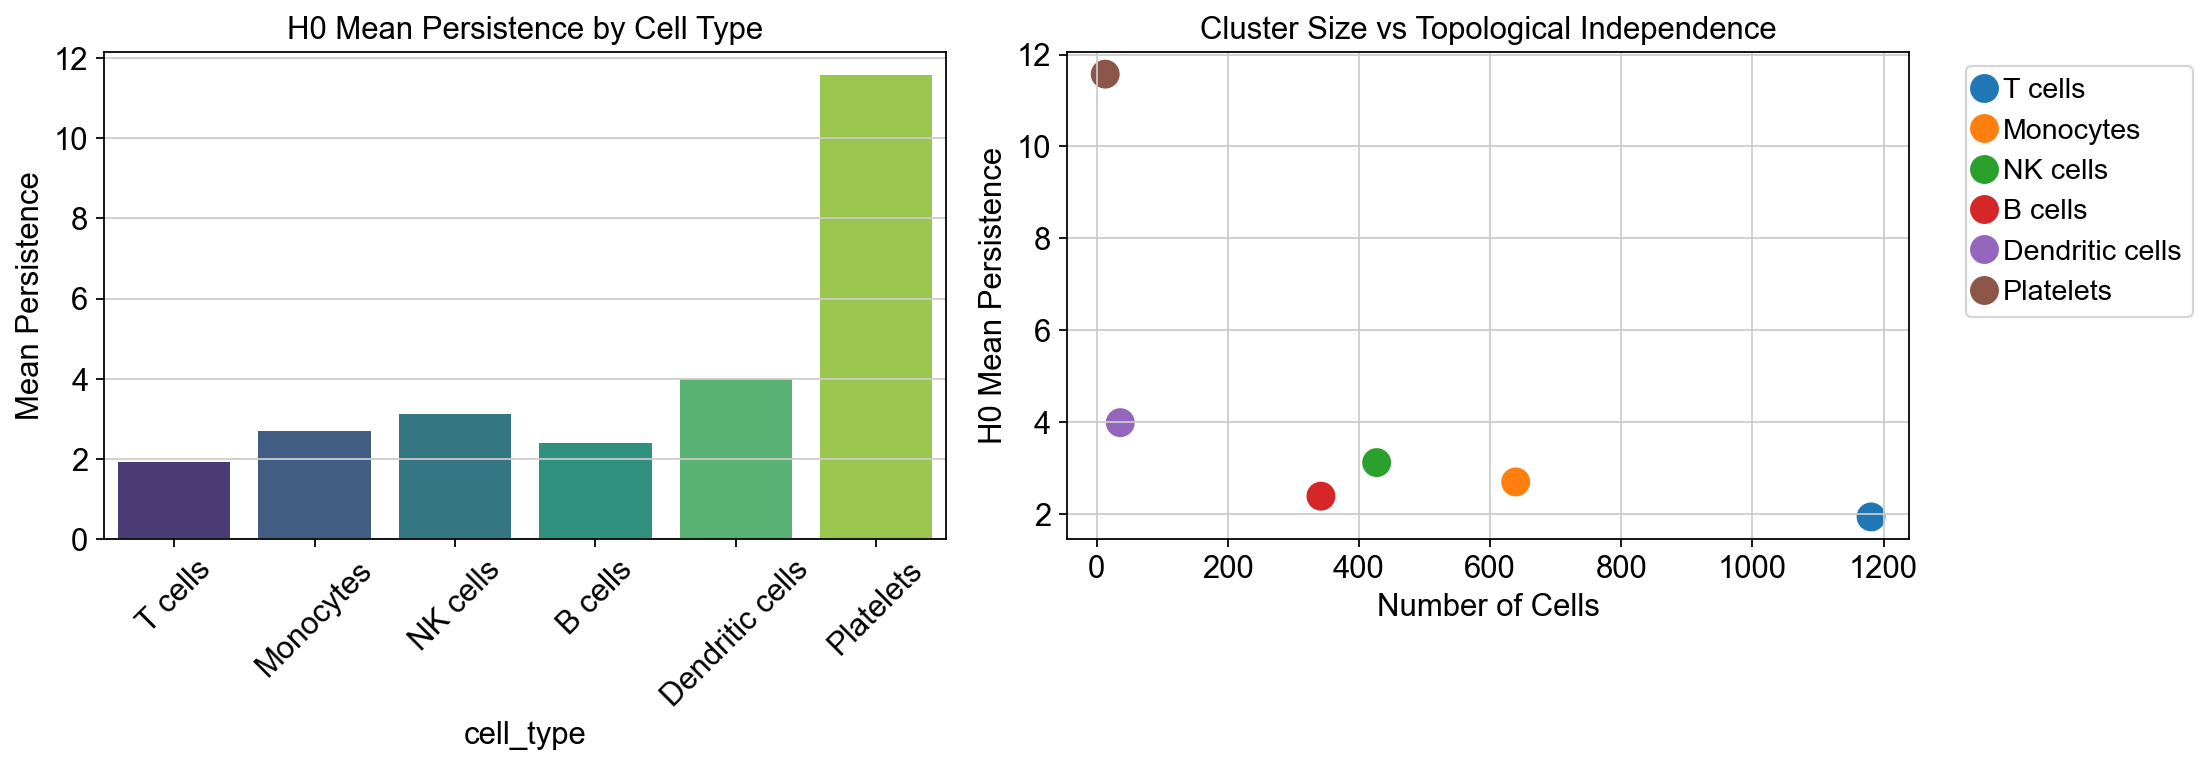

In [18]:
# 可视化
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# H0 mean persistence vs cell type
sns.barplot(data=topo_stats, x="cell_type", y="mean_persistence_h0", 
            ax=axes[0], palette="viridis")
axes[0].set_title("H0 Mean Persistence by Cell Type")
axes[0].set_ylabel("Mean Persistence")
axes[0].tick_params(axis="x", rotation=45)

# 细胞数 vs H0 persistence
sns.scatterplot(data=topo_stats, x="n_cells", y="mean_persistence_h0", 
                hue="cell_type", s=200, ax=axes[1], palette="tab10")
axes[1].set_title("Cluster Size vs Topological Independence")
axes[1].set_xlabel("Number of Cells")
axes[1].set_ylabel("H0 Mean Persistence")
axes[1].legend(bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()
plt.savefig(config.FIGURES_DIR / "03_topo_annotation_link.png", dpi=150, bbox_inches="tight")
plt.show()

In [19]:
# 打印汇总
print("\n细胞类型拓扑特征汇总:")
print(topo_stats[["cluster", "cell_type", "n_cells", "mean_persistence_h0", "mean_persistence_h1"]].to_string(index=False))


细胞类型拓扑特征汇总:
 cluster       cell_type  n_cells  mean_persistence_h0  mean_persistence_h1
       0         T cells     1181             1.934010             0.157091
       1       Monocytes      639             2.695613             0.226156
       2        NK cells      427             3.116785             0.285229
       3         B cells      342             2.385915             0.206237
       4 Dendritic cells       36             3.986361             0.322799
       5       Platelets       13            11.575632             0.642049


## 7. 保存最终数据

In [20]:
save_h5ad(adata, "pbmc3k_annotated.h5ad")
print("带注释的数据已保存")

带注释的数据已保存
